In [14]:
import os, sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm

BASE_PATH = Path('/gpfs/gibbs/project/papademetris/jg3279')
DATA_PATH = BASE_PATH / 'data' / 'USenhance_2023_split'
OUTPUT_PATH = BASE_PATH / 'USFM' / 'week8' / 'imagenet_vit_last3layers'
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPUs: {torch.cuda.device_count()}')

CONFIG = {
    'batch_size': 64,
    'num_epochs': 50,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'num_workers': 8,
    'organ_classes': ['breast', 'carotid', 'kidney', 'liver', 'thyroid']
}

Device: cuda
GPUs: 2


In [15]:
class OrganDataset(Dataset):
    def __init__(self, data_path, split='train', transform=None):
        self.split = split
        self.transform = transform
        self.organ_classes = CONFIG['organ_classes']
        self.organ_to_idx = {organ: idx for idx, organ in enumerate(self.organ_classes)}
        self.data_path = Path(data_path) / split
        self.samples = []
        self._load_samples()
    
    def _load_samples(self):
        for organ in self.organ_classes:
            organ_path = self.data_path / organ
            if organ_path.exists():
                for quality_dir in organ_path.glob('*quality'):
                    for img_file in quality_dir.glob('*.png'):
                        self.samples.append({
                            'path': img_file,
                            'organ': organ,
                            'organ_idx': self.organ_to_idx[organ],
                            'quality': quality_dir.name
                        })
        print(f'✓ {self.split.upper()}: {len(self.samples)} images')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return {
            'image': img,
            'organ_label': sample['organ_idx'],
            'organ_name': sample['organ'],
            'quality': sample['quality']
        }

print('✓ Dataset class defined')

✓ Dataset class defined


In [16]:
class OrganClassifierFrozen(nn.Module):
    def __init__(self, backbone, num_classes=5):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        backbone_model = backbone.module if isinstance(backbone, nn.DataParallel) else backbone
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(next(backbone.parameters()).device)
            features = backbone_model.forward_features(dummy_input)
            embedding_dim = features.shape[-1]
        self.embedding_dim = embedding_dim
        print(f'✓ Embedding dim: {embedding_dim}')
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self._freeze_all_but_last_3_layers()
    
    def _freeze_all_but_last_3_layers(self):
        backbone_model = self.backbone.module if isinstance(self.backbone, nn.DataParallel) else self.backbone
        for param in backbone_model.parameters():
            param.requires_grad = False
        if hasattr(backbone_model, 'blocks'):
            for block in backbone_model.blocks[-3:]:
                for param in block.parameters():
                    param.requires_grad = True
        if hasattr(backbone_model, 'norm'):
            for param in backbone_model.norm.parameters():
                param.requires_grad = True
        print('✓ Frozen all except last 3 blocks')
    
    def forward(self, x):
        backbone = self.backbone.module if isinstance(self.backbone, nn.DataParallel) else self.backbone
        features = backbone.forward_features(x)
        cls_token = features[:, 0, :]
        logits = self.classifier(cls_token)
        return logits
    
    def extract_features(self, x):
        backbone = self.backbone.module if isinstance(self.backbone, nn.DataParallel) else self.backbone
        features = backbone.forward_features(x)
        cls_token = features[:, 0, :]
        return cls_token

print('✓ Model class defined')

✓ Model class defined


In [17]:
print('Loading ImageNet ViT-Base...')
backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=1000)
print('✓ ImageNet pretrained ViT loaded')

if torch.cuda.device_count() > 1:
    backbone = nn.DataParallel(backbone)
backbone = backbone.to(device)

Loading ImageNet ViT-Base...
✓ ImageNet pretrained ViT loaded


In [18]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = OrganDataset(DATA_PATH, split='train', transform=train_transform)
val_dataset = OrganDataset(DATA_PATH, split='val', transform=val_transform)
test_dataset = OrganDataset(DATA_PATH, split='test', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print('✓ Data loaded')

✓ TRAIN: 1480 images
✓ VAL: 310 images
✓ TEST: 310 images
✓ Data loaded


In [19]:
CONFIG['num_classes'] = 5

In [20]:
model = OrganClassifierFrozen(backbone=backbone, num_classes=CONFIG['num_classes'])
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Total params: {total_params:,}')
print(f'✓ Trainable params: {trainable_params:,}')
print(f'✓ Frozen params: {total_params - trainable_params:,}')
print(f'  Ratio: {trainable_params/total_params*100:.2f}% trainable')

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6)

print('✓ Optimizer ready')

✓ Embedding dim: 768
✓ Frozen all except last 3 blocks
✓ Total params: 86,963,949
✓ Trainable params: 21,661,445
✓ Frozen params: 65,302,504
  Ratio: 24.91% trainable
✓ Optimizer ready


In [21]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['organ_label'].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating', leave=False):
            images = batch['image'].to(device)
            labels = batch['organ_label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / total

print('✓ Training functions defined')

✓ Training functions defined


In [22]:
print('\nTraining...')
train_losses, train_accs, val_losses, val_accs = [], [], [], []
best_val_acc = 0
best_model_path = OUTPUT_PATH / 'best_model.pth'
patience = 15
patience_counter = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch [{epoch+1}/{CONFIG["num_epochs"]}]', end=' | ')
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}', end='')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'val_acc': val_acc}, best_model_path)
        print(' ✓')
    else:
        patience_counter += 1
        print()
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'Training done. Best Val Acc: {best_val_acc:.4f}')


Training...
Epoch [1/50] | 

Train: 0.7258/0.6642 | Val: 0.4517/0.8419 ✓
Epoch [2/50] | 

Train: 0.2131/0.9284 | Val: 0.3281/0.9065 ✓
Epoch [3/50] | 

Train: 0.2239/0.9338 | Val: 0.3311/0.9097 ✓
Epoch [4/50] | 

Train: 0.1702/0.9473 | Val: 0.2086/0.9387 ✓
Epoch [5/50] | 

...

Train: 0.0035/0.9986 | Val: 0.0458/0.9871
Epoch [40/50] | 

Train: 0.0074/0.9973 | Val: 0.0472/0.9806
Epoch [41/50] | 

Train: 0.0025/0.9986 | Val: 0.0466/0.9806
Epoch [42/50] | 

Train: 0.0023/1.0000 | Val: 0.0464/0.9839
Epoch [43/50] | 

Train: 0.0057/0.9973 | Val: 0.0439/0.9839
Early stopping at epoch 42
Training done. Best Val Acc: 0.9968


In [23]:
# 检查参数是否真的被冻结了
backbone_model = backbone.module if isinstance(backbone, nn.DataParallel) else backbone

print("检查冻结状态:")
print(f"Block 0 requires_grad: {backbone_model.blocks[0].attn.qkv.weight.requires_grad}")
print(f"Block 8 requires_grad: {backbone_model.blocks[8].attn.qkv.weight.requires_grad}")
print(f"Block 9 requires_grad: {backbone_model.blocks[9].attn.qkv.weight.requires_grad}")
print(f"Block 10 requires_grad: {backbone_model.blocks[10].attn.qkv.weight.requires_grad}")
print(f"Block 11 requires_grad: {backbone_model.blocks[11].attn.qkv.weight.requires_grad}")

# 看训练曲线
print("\n最后5个epoch的结果:")
for i in range(-5, 0):
    print(f"Epoch {len(train_losses)+i}: Train={train_accs[i]:.4f}, Val={val_accs[i]:.4f}")

检查冻结状态:
Block 0 requires_grad: False
Block 8 requires_grad: False
Block 9 requires_grad: True
Block 10 requires_grad: True
Block 11 requires_grad: True

最后5个epoch的结果:
Epoch 38: Train=0.9986, Val=0.9871
Epoch 39: Train=0.9973, Val=0.9806
Epoch 40: Train=0.9986, Val=0.9806
Epoch 41: Train=1.0000, Val=0.9839
Epoch 42: Train=0.9973, Val=0.9839


/tmp/tmp.2F8v40gaVc/ipykernel_3797367/1815294010.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path)


Test Loss: 0.0900
Test Accuracy: 0.9742


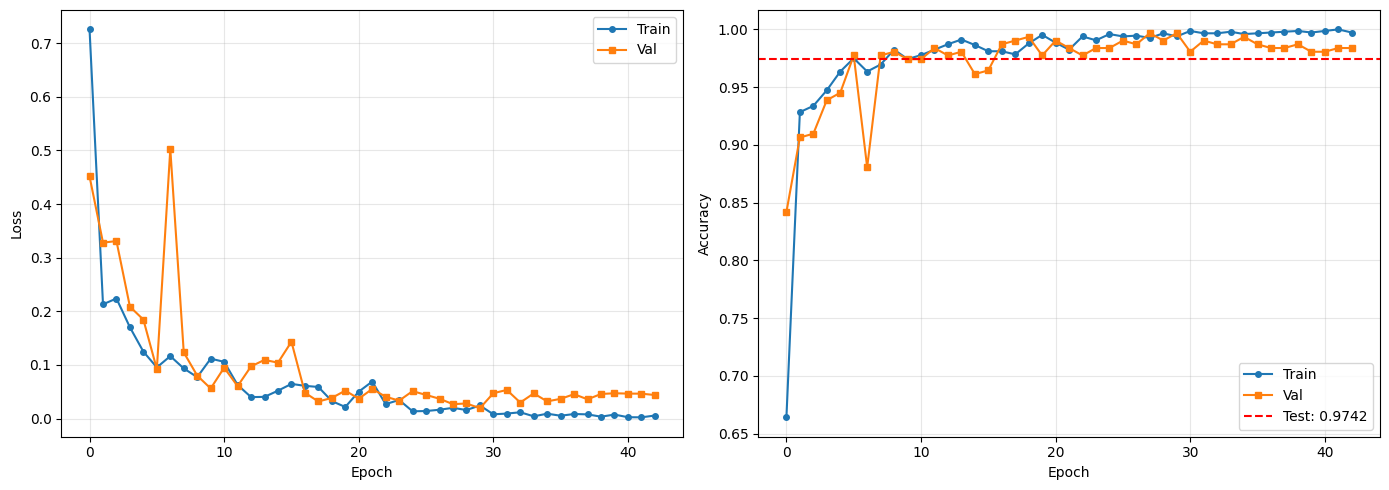

✓ Saved curves


In [24]:
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train', marker='o', markersize=4)
axes[0].plot(val_losses, label='Val', marker='s', markersize=4)
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', marker='o', markersize=4)
axes[1].plot(val_accs, label='Val', marker='s', markersize=4)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved curves')